In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
import pandas as pd

In [2]:
all_data = json.load(open('./raw_data.json', 'r'))

In [3]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    if entry['task'] == 'recognize':
        index = 0
        for item in entry['items']:
            index += 1
            data.append({
                "ab": entry['ab'],
                "index": index,
                "worker": entry['workerId'],
                "file": item['file'],
                "sample": item.get('sample'),
                "success": item['file'] == item['choices'][item['selected']]['file'],
                "time": (item['endTime'] - item['startTime']) / 1000.0
            })
data = pd.DataFrame(data)
data.shape

(2940, 7)

Text(0.5, 1.0, 'Worker performance')

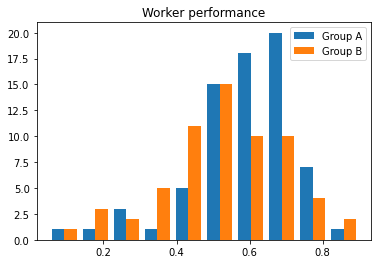

In [4]:
plt.hist([data[data['ab']=='A'].groupby('worker')['success'].mean(),
          data[data['ab']=='B'].groupby('worker')['success'].mean()])
plt.legend(['Group A','Group B'])
plt.title('Worker performance')

Text(0.5, 1.0, 'Worker speed vs success rate')

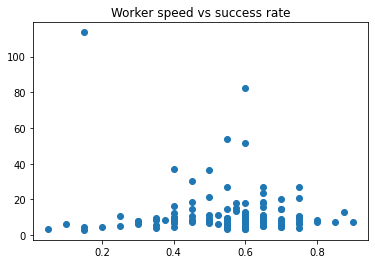

In [5]:
plt.scatter(
    data.groupby('worker')['success'].mean(),
    data.groupby('worker')['time'].mean())
plt.title('Worker speed vs success rate')

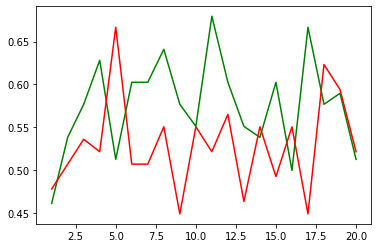

In [20]:
D=data[data['ab']=='A'].groupby(['index'])['success'].mean()
plt.plot(D, color='green')
D=data[data['ab']=='B'].groupby(['index'])['success'].mean()
plt.plot(D, color='red')

In [40]:
data.groupby(['ab','success'])['time'].mean()

ab  success
A   False      15.259500
    True       10.727375
B   False      11.696790
    True        9.718357
Name: time, dtype: float64

In [41]:
R = data.groupby(['ab'])['success'].mean()
R

ab
A    0.575641
B    0.530435
Name: success, dtype: float64

In [42]:
5/(1/R-1)

ab
A    6.782477
B    5.648148
Name: success, dtype: float64

In [43]:
for ab in ['A', 'B']:
    N = (data['ab']==ab).sum()
    q1 = binom.ppf(0.05, N, R[ab])
    q2 = binom.ppf(0.95, N, R[ab])
    print(f"Group {ab}: {q1/N:.2f} .. {q2/N:.2f}")

Group A: 0.56 .. 0.60
Group B: 0.51 .. 0.55
